# Hepatic Vasculature Visualization — First Case

Visualizes, from the first case in `data/0_test_nifti`:
- `VenaHepaticaMedia`, `VenaHepaticaIzquierda`, `VenaHepaticaDerecha`
- the 4 `PediculoPortal*` branches (Anterior/Posterior Derecho, Derecho, Izquierdo)
- `IVC`

Two views:
1. A static matplotlib 3D skeleton plot (skimage thinning, colour-coded by structure).
2. The interactive `multi_viewer.py` Dash app (`skeleton-viewer/`), with a parameter
   cell to pick which of the 8 structures actually get loaded into the viewer.

> Run with the `graph-learning/.venv` kernel (has `nibabel`, `scikit-image`).

In [1]:
import sys
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from skimage.morphology import skeletonize

DATA_ROOT = Path('data/0_test_nifti')
assert DATA_ROOT.exists(), f'{DATA_ROOT} not found — run from continuity/'

case = sorted(DATA_ROOT.glob('RMV*'))[0]
print(f'Case: {case.name}')

STRUCTURES = [
    'classVenaHepaticaMedia.nii.gz',
    'classVenaHepaticaIzquierda.nii.gz',
    'classVenaHepaticaDerecha.nii.gz',
    'classPediculoPortalAnteriorDerecho.nii.gz',
    'classPediculoPortalDerecho.nii.gz',
    'classPediculoPortalIzquierdo.nii.gz',
    'classPediculoPortalPosteriorDerecho.nii.gz',
    'classIVC.nii.gz',
]
structure_paths = {name: case / name for name in STRUCTURES}
for name, path in structure_paths.items():
    assert path.exists(), f'missing {path}'
print(f'{len(structure_paths)} structures found')

Case: RMV2025_0001_CT_NCT_HBP_X
8 structures found


In [2]:
# ---------- load masks and skeletonize each structure ----------
def load_thinning(mask):
    skeleton = skeletonize(mask)
    return np.array(np.where(skeleton)).T

masks = {name: (nib.load(str(p)).get_fdata() > 0) for name, p in structure_paths.items()}
skeletons = {name: load_thinning(m) for name, m in masks.items()}

for name, pts in skeletons.items():
    print(f'{name:45s} voxels={int(masks[name].sum()):6d}  skeleton_pts={len(pts):5d}')

classVenaHepaticaMedia.nii.gz                 voxels=  9646  skeleton_pts=  309
classVenaHepaticaIzquierda.nii.gz             voxels=  3341  skeleton_pts=   98
classVenaHepaticaDerecha.nii.gz               voxels= 22278  skeleton_pts=  730
classPediculoPortalAnteriorDerecho.nii.gz     voxels=  2901  skeleton_pts=   84
classPediculoPortalDerecho.nii.gz             voxels=  4554  skeleton_pts=   38
classPediculoPortalIzquierdo.nii.gz           voxels=  7452  skeleton_pts=  181
classPediculoPortalPosteriorDerecho.nii.gz    voxels=  8832  skeleton_pts=  255
classIVC.nii.gz                               voxels= 18975  skeleton_pts= 1003


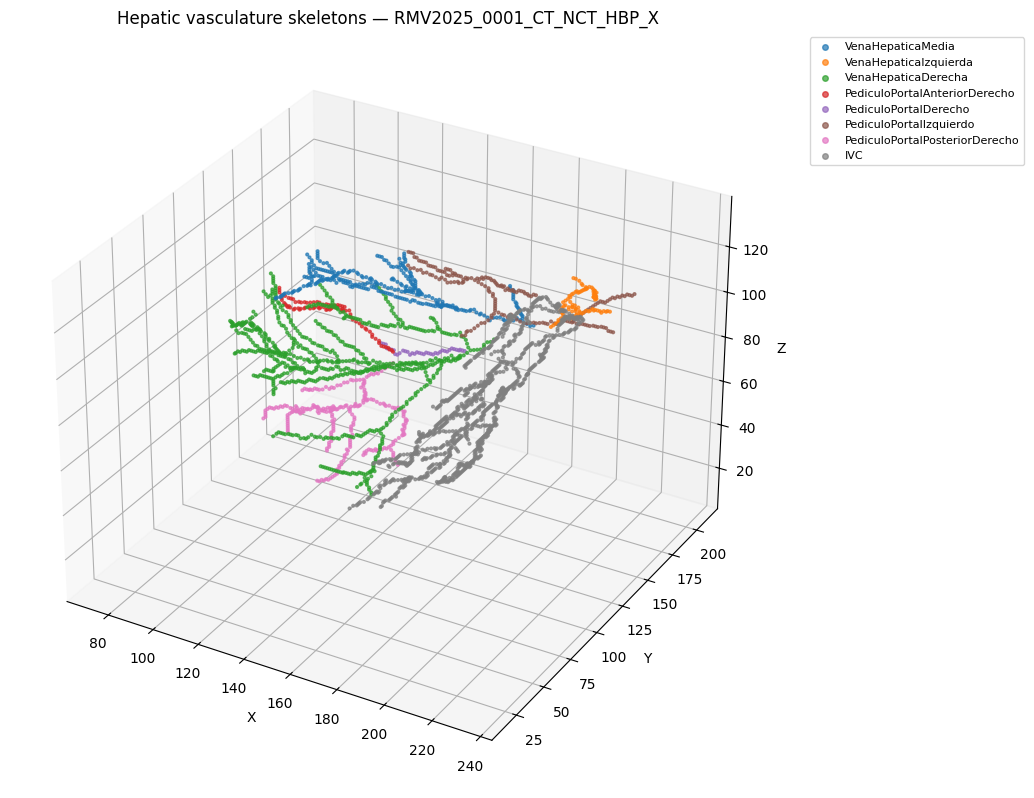

In [3]:
# ---------- static 3D visualization (matplotlib) ----------
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab10.colors
for i, (name, pts) in enumerate(skeletons.items()):
    if len(pts) == 0:
        continue
    label = name.replace('class', '').replace('.nii.gz', '')
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=4, alpha=0.7, color=colors[i % 10], label=label)

ax.set_title(f'Hepatic vasculature skeletons — {case.name}')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend(fontsize=8, markerscale=2, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Interactive viewer (`multi_viewer.py`)

Launches the Dash-based `MultiViewer` (from `../skeleton-viewer/multi_viewer.py`) with the
same structures loaded as NIfTI volume layers, colour-coded and independently toggleable
in the browser UI.

Which structures actually get added is controlled by the `SELECTED` dict in the parameter
cell below — flip any entry to `False` to skip it.

> Requires `dash` (pulls in `plotly` as a dependency) — not currently installed in
> `graph-learning/.venv`. Run the install cell once if you get `ModuleNotFoundError: dash`.

In [4]:
# Run once if `dash` is not installed in this kernel's environment.
# %pip install -q dash

In [5]:
# ---------- parameter: pick which structures to launch in the multi-viewer ----------
SELECTED = {
    'classVenaHepaticaMedia.nii.gz': True,
    'classVenaHepaticaIzquierda.nii.gz': True,
    'classVenaHepaticaDerecha.nii.gz': True,
    'classPediculoPortalAnteriorDerecho.nii.gz': True,
    'classPediculoPortalDerecho.nii.gz': True,
    'classPediculoPortalIzquierdo.nii.gz': True,
    'classPediculoPortalPosteriorDerecho.nii.gz': True,
    'classIVC.nii.gz': True,
}
selected_paths = [structure_paths[name] for name, on in SELECTED.items() if on]
print(f'{len(selected_paths)}/{len(SELECTED)} structures selected for the viewer')
for p in selected_paths:
    print(f'  + {p.name}')

8/8 structures selected for the viewer
  + classVenaHepaticaMedia.nii.gz
  + classVenaHepaticaIzquierda.nii.gz
  + classVenaHepaticaDerecha.nii.gz
  + classPediculoPortalAnteriorDerecho.nii.gz
  + classPediculoPortalDerecho.nii.gz
  + classPediculoPortalIzquierdo.nii.gz
  + classPediculoPortalPosteriorDerecho.nii.gz
  + classIVC.nii.gz


In [6]:
# ---------- launch MultiViewer with the selected structures ----------
# Blocking call: opens a browser tab and runs the Dash server until the kernel is
# interrupted (Kernel > Interrupt). debug=False avoids the Werkzeug reloader, which
# doesn't play well spawned from inside a notebook process.
SKELETON_VIEWER_DIR = (Path.cwd() / '../skeleton-viewer').resolve()
assert SKELETON_VIEWER_DIR.exists(), f'{SKELETON_VIEWER_DIR} not found'
if str(SKELETON_VIEWER_DIR) not in sys.path:
    sys.path.insert(0, str(SKELETON_VIEWER_DIR))

from multi_viewer import MultiViewer

viewer = MultiViewer()
for p in selected_paths:
    viewer.add_volume(str(p), name=p.name.replace('class', '').replace('.nii.gz', ''), opacity=0.8)

viewer.run(host='127.0.0.1', port=8050, debug=False, open_browser=True)

/Users/lois/.virtualenvs/skeletonization/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
